# Pipeline de Machine Learning — Q1: Alfabetização Municipal

Este notebook parte diretamente da base **município-ano** já preparada no notebook anterior e desenvolve a pergunta de negócio:

> **Q1 — Quais fatores mais ajudam a explicar/predizer a alfabetização futura?**

A estratégia metodológica é:

- **2024**: desenvolvimento, comparação de modelos, cross-validation, otimização e seleção do modelo;
- **2025**: teste temporal final, usado somente após o encerramento das decisões de desenvolvimento;
- todo pré-processamento que aprende parâmetros dos dados permanece **dentro do `Pipeline` do scikit-learn**;
- a target não é imputada;
- identificadores municipais são preservados apenas para rastreabilidade e análise dos erros;
- a etapa final interpreta a Random Forest com **Permutation Importance** e **SHAP global**.

A expressão **“impactam”** é usada neste notebook no sentido de **importância, associação ou poder preditivo**. Os modelos não permitem concluir causalidade.

O notebook foi estruturado para ser executado e auditado por um analista júnior.


## 1. Ambiente, dependências e leitura

A entrada oficial é o Parquet consolidado pelo notebook anterior:

`/content/drive/Othercomputers/@lua2026/01_projects/2026_FIAP/desafios/postech-challenge-3/data/processed/modelage/dados_modelagem_municipio_ano_2024_2025.parquet`

A base já está na granularidade **município-ano**. Portanto, este notebook não relê a base aluno-ano e não repete a etapa de agregação.

In [1]:
# Caso o computador tenho poder de processamento suficiente para a tarefa, troque o valor da variável AMBIENTE_COLAB para False.
AMBIENTE_COLAB = True

In [2]:
if AMBIENTE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    from src.config import PROCESSED_DATA_DIR

Mounted at /content/drive


In [3]:
if AMBIENTE_COLAB:
    !pip install -q pyarrow scikit-learn shap joblib

In [4]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RANDOM_STATE = 42

if AMBIENTE_COLAB:
    DIR_MODELAGEM = Path(
        '/content/drive/Othercomputers/@lua2026/01_projects/2026_FIAP/desafios/postech-challenge-3/data/processed/modelagem/dados_modelagem_municipio_ano_2024_2025.parquet'
    )

else:
    DIR_MODELAGEM = PROCESSED_DATA_DIR / 'modelagem'


if not DIR_MODELAGEM.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {DIR_MODELAGEM}\n'
        'Confirme se o Google Drive foi montado e se a base está no caminho esperado.'
    )

dados = pd.read_parquet(DIR_MODELAGEM)

print(f'Dimensões: {dados.shape[0]:,} linhas × {dados.shape[1]:,} colunas')
display(dados.head())
display(dados['ano'].value_counts().sort_index())

Dimensões: 11,073 linhas × 50 colunas


,ano,id_uf,id_municipio,nome_municipio,alunos,taxa_realizada,proficiencia_media,escolas,pct_rede_municipal,ctx_atu_educacao_infantil,ctx_atu_creche,ctx_atu_pre_escola,ctx_atu_fundamental_anos_iniciais,ctx_atu_fundamental_1_ano,ctx_atu_fundamental_2_ano,ctx_atu_fundamental_3_ano,ctx_atu_fundamental_4_ano,ctx_atu_fundamental_5_ano,ctx_atlas_idhm_longevidade,ctx_atlas_taxa_analfabetismo_11a14,ctx_atlas_taxa_analfabetismo_15a17,ctx_atlas_taxa_analfabetismo_15mais,ctx_atlas_taxa_frequencia_0a3,ctx_atlas_expectativa_anos_estudo,ctx_atlas_indice_gini,ctx_atlas_taxa_trabalho_infantil_10a14,ctx_atlas_taxa_maes_10a14,ctx_atlas_taxa_maes_chefes_familia,ctx_atlas_taxa_fora_escola_4a5,ctx_atlas_taxa_fora_escola_6a14,ctx_atlas_taxa_frequencia_liquida_fundamental,ctx_atlas_percentual_domicilios_agua,ctx_atlas_percentual_domicilios_energia,ctx_atlas_taxa_densidade_domiciliar,ctx_fundeb_nse_uf,populacao,ctx_ibge_area_km2,ctx_ibge_pct_populacao_rural,ctx_ibge_pct_esgoto_adequado,ctx_ibge_renda_domiciliar_per_capita_media,taxa_lag1,proficiencia_lag1,participacao_lag1,meta,ctx_inep_uf_media_portugues_lag1,ctx_inep_uf_percentual_participacao_lag1,risco_educacional,risco_nao_atingir_meta,distancia_ate_a_meta,esforco_pactuado
0,2024,11,1100015,Alta Floresta D'Oeste,275,68.000,752.593,8,100.000,18.800,14.800,20.900,22.100,23.400,21.300,23.400,21.000,20.600,0.763,1.220,1.520,11.990,4.890,8.670,0.580,9.080,0.000,14.510,60.820,4.320,92.880,93.690,93.980,22.580,49.335,"22,853.000","7,067.127",0.397,0.005,"1,210.600",64.550,758.330,89.370,67.000,759.436,88.100,0.000,0.000,1.000,2.450
1,2024,11,1100023,Ariquemes,1066,65.854,748.307,18,100.000,23.500,20.500,25.200,25.000,24.900,23.200,25.800,26.000,25.500,0.806,1.550,1.090,7.900,9.890,9.180,0.530,7.890,0.000,18.070,44.660,2.790,91.310,98.540,98.580,27.150,49.335,"108,573.000","4,426.571",0.133,0.020,"1,458.570",62.300,757.100,89.790,65.000,759.436,88.100,0.000,0.000,0.854,2.700
2,2024,11,1100031,Cabixi,75,76.000,759.857,2,100.000,19.400,36.500,15.600,14.300,13.400,14.000,17.400,14.800,12.200,0.757,0.620,1.060,13.630,12.490,10.090,0.510,12.160,1.120,7.030,33.080,1.970,92.810,95.490,96.360,19.930,49.335,"5,690.000","1,314.352",0.468,0.016,"1,323.790",69.100,767.876,90.480,71.000,759.436,88.100,0.000,0.000,5.000,1.900
3,2024,11,1100049,Cacoal,951,66.351,747.937,19,83.701,17.400,17.700,17.300,20.721,21.593,22.260,21.662,17.402,19.280,0.821,1.010,0.800,8.290,11.380,9.740,0.570,11.800,0.680,12.800,37.590,2.390,93.020,97.960,98.890,20.500,49.335,"97,637.000","3,793.000",0.172,0.672,"1,625.880",62.510,755.564,84.440,65.000,759.436,88.100,0.000,0.000,1.351,2.490
4,2024,11,1100056,Cerejeiras,244,66.803,749.646,4,100.000,17.700,14.800,19.900,22.400,22.800,24.000,21.600,22.100,21.000,0.799,1.140,0.750,10.290,13.450,10.220,0.500,10.500,0.000,25.880,38.730,1.460,93.470,97.530,98.850,16.660,49.335,"16,975.000","2,783.300",0.112,0.580,"1,554.330",58.530,746.463,92.120,62.000,759.436,88.100,0.000,0.000,4.803,3.470


,count
ano,
2024,5517
2025,5556


## 2. Estratégia de desenvolvimento e teste temporal

O ano de **2024** é usado para desenvolvimento, comparação de modelos, tuning e seleção por **5-fold cross-validation**.

Após a seleção, são geradas **previsões out-of-fold (OOF) em 2024**. Cada município é previsto por um modelo que não foi treinado naquele próprio município, permitindo um diagnóstico *in-time* sem reservar um holdout fixo de 20%.

As métricas OOF de 2024 são tratadas como **diagnóstico de desenvolvimento**, pois a escolha do modelo e dos hiperparâmetros também foi feita com 2024. Elas não substituem um teste externo independente.

O ano de **2025** permanece como **teste temporal final (out-of-time)**. Ele não é usado para selecionar modelo, hiperparâmetros, estratégia de imputação ou qualquer outra decisão de desenvolvimento.


In [5]:
ANO_DESENVOLVIMENTO = 2024
ANO_TESTE_FINAL = 2025

DADOS_DESENVOLVIMENTO = dados.loc[
    dados['ano'].eq(ANO_DESENVOLVIMENTO)
].copy()

DADOS_TESTE_FINAL = dados.loc[
    dados['ano'].eq(ANO_TESTE_FINAL)
].copy()

assert len(DADOS_DESENVOLVIMENTO) > 0
assert len(DADOS_TESTE_FINAL) > 0
assert DADOS_DESENVOLVIMENTO['ano'].eq(2024).all()
assert DADOS_TESTE_FINAL['ano'].eq(2025).all()

print(f'Desenvolvimento 2024: {len(DADOS_DESENVOLVIMENTO):,} municípios')
print(f'Teste temporal 2025: {len(DADOS_TESTE_FINAL):,} municípios')


Desenvolvimento 2024: 5,517 municípios
Teste temporal 2025: 5,556 municípios


## 3. Auditoria inicial da base de modelagem

Antes de criar qualquer modelo, verificamos:

- distribuição temporal;
- targets disponíveis;
- nulos remanescentes;
- tipos das variáveis;
- presença das colunas necessárias.

Os nulos em `X` são esperados e serão tratados dentro dos pipelines.

In [6]:
TARGET_Q1 = 'taxa_realizada'

if TARGET_Q1 not in dados.columns:
    raise KeyError(f'Target ausente na base: {TARGET_Q1}')

auditoria = pd.DataFrame({
    'dtype': dados.dtypes.astype(str),
    'nulos': dados.isna().sum(),
    'nulos_pct': dados.isna().mean().mul(100),
    'n_unicos': dados.nunique(dropna=True),
}).sort_values('nulos_pct', ascending=False)

display(auditoria.head(30))
display(dados.groupby('ano')[[TARGET_Q1]].agg(['count', 'mean']))

del auditoria


,dtype,nulos,nulos_pct,n_unicos
participacao_lag1,float64,399,3.603,4672
ctx_atu_creche,float64,329,2.971,539
esforco_pactuado,float64,247,2.231,4716
proficiencia_lag1,float64,215,1.942,9919
taxa_lag1,float64,215,1.942,6086
risco_nao_atingir_meta,float64,132,1.192,2
distancia_ate_a_meta,float64,132,1.192,9141
meta,float64,132,1.192,105
ctx_atu_pre_escola,float64,112,1.011,545
ctx_atu_educacao_infantil,float64,111,1.002,556


taxa_realizada       
              count   mean
ano                       
2024           5517 63.280
2025           5556 72.162

## 4. Definição das features e bloqueio de leakage

Variáveis derivadas do resultado corrente, identificadores e metadados da avaliação corrente não entram em `X`.

`id_uf` e `id_municipio` continuam disponíveis separadamente apenas para identificar municípios nas análises posteriores.

In [7]:
COLUNAS_CHAVE = ['ano', 'id_uf', 'id_municipio']

FEATURES_PROIBIDAS = {
    'taxa_realizada',
    'nivel_realizado',
    'proficiencia_media',
    'distancia_ate_a_meta',
    'variacao_ica',
    'risco_educacional',
    'risco_nao_atingir_meta',
    'alunos',
    'escolas',
    'pct_rede_municipal',
    'ano',
    'id_uf',
    'id_municipio',
    'nome_municipio',
}

FEATURES_Q1 = sorted([
    c for c in dados.columns
    if c not in FEATURES_PROIBIDAS
    and c not in {'meta', 'esforco_pactuado', 'log_populacao'}
])

vazamento = set(FEATURES_Q1) & FEATURES_PROIBIDAS
assert not vazamento, f'Q1: leakage encontrado: {sorted(vazamento)}'
print(f'Q1: {len(FEATURES_Q1)} features')


Q1: 36 features


## 5. Engenharia de atributos

Para Q1, a engenharia é deliberadamente pequena e interpretável.

Nos **modelos lineares**, é criada:

- `log_populacao = log1p(populacao)`, para oferecer uma representação menos assimétrica da população.

Na **Random Forest**, essa transformação não é usada: como `log_populacao` é uma transformação monotônica de `populacao`, manter ambas introduziria informação redundante e poderia dividir artificialmente a importância entre duas representações da mesma variável. Portanto, a Random Forest utiliza somente `populacao`.

A transformação destinada aos modelos lineares permanece encapsulada em `FunctionTransformer`, garantindo sua reprodução dentro do pipeline.


In [8]:
def criar_features(X):
    X = X.copy()

    if 'populacao' in X.columns:
        X['log_populacao'] = np.log1p(
            pd.to_numeric(X['populacao'], errors='coerce').clip(lower=0)
        )

    return X


engenharia = FunctionTransformer(
    criar_features,
    validate=False
)


## 6. Pipeline de pré-processamento

O pré-processamento é separado conforme a família do modelo:

- **regressão linear simples**: usa apenas `taxa_lag1`, com imputação por mediana;
- **regressão linear múltipla (OLS)**: usa as features de Q1, com imputação e One-Hot Encoding; nas categóricas, a primeira categoria é removida para evitar redundância perfeita entre dummies;
- **Ridge**: imputação + scaling, adequado à regularização L2;
- **modelos de árvore**: imputação sem scaling.

A imputação e as transformações que aprendem parâmetros são ajustadas dentro de cada fold da cross-validation, evitando data leakage.

In [9]:
pipeline_numerico_linear = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
    ('scaler', StandardScaler()),
])

pipeline_numerico_ols = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
])

pipeline_numerico_arvore = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True,
        )
    ),
])

pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False,
        )
    ),
])

pipeline_categorico_ols = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False,
        )
    ),
])

seletor_numerico = make_column_selector(dtype_include=np.number)
seletor_categorico = make_column_selector(dtype_exclude=np.number)

preprocessor_linear = ColumnTransformer([
    ('num', pipeline_numerico_linear, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

preprocessor_linear_multipla = ColumnTransformer([
    ('num', pipeline_numerico_ols, seletor_numerico),
    ('cat', pipeline_categorico_ols, seletor_categorico),
])

preprocessor_linear_simples = ColumnTransformer([
    (
        'taxa_lag1',
        SimpleImputer(strategy='median', keep_empty_features=True),
        ['taxa_lag1'],
    ),
], remainder='drop')

preprocessor_arvore = ColumnTransformer([
    ('num', pipeline_numerico_arvore, seletor_numerico),
    ('cat', pipeline_categorico, seletor_categorico),
])

## 7. Funções auxiliares

As funções abaixo padronizam a preparação da regressão de Q1 e a avaliação por cross-validation.

A target não é imputada. Registros com `taxa_realizada == 0` são removidos da modelagem antes da criação de `X` e `y`.


In [10]:
def montar_xy(base, features, target):
    mascara_target_valido = base[target].notna() & base[target].ne(0)
    idx = base.index[mascara_target_valido]

    X = base.loc[idx, features].copy()
    y = base.loc[idx, target].copy()
    chaves = base.loc[idx, COLUNAS_CHAVE].copy()

    assert X.index.equals(y.index)
    assert not y.isna().any()
    assert not y.eq(0).any()

    return X, y, chaves


def resumir_cv_regressao(nome, resultado):
    return {
        'modelo': nome,
        'MAE_treino': -np.mean(resultado['train_mae']),
        'MAE_CV': -np.mean(resultado['test_mae']),
        'MAE_CV_std': np.std(-resultado['test_mae']),
        'RMSE_CV': -np.mean(resultado['test_rmse']),
        'R2_CV': np.mean(resultado['test_r2']),
        'gap_MAE': (
            -np.mean(resultado['test_mae'])
            - (-np.mean(resultado['train_mae']))
        ),
    }


def metricas_regressao(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


## 8. Q1 — Regressão da taxa de alfabetização

### 8.1 Preparação

O objetivo é prever `taxa_realizada`.

O desenvolvimento ocorre apenas em 2024. O conjunto de 2025 permanece reservado para a avaliação temporal final.

Municípios com `taxa_realizada == 0` são removidos antes da modelagem. Para que a comparação com o baseline `taxa_lag1` seja homogênea, a cross-validation e o diagnóstico OOF de 2024 usam a **mesma amostra em que `taxa_lag1` está disponível**.

Após a seleção do modelo, as previsões OOF permitem avaliar 2024 sem criar um holdout fixo. Em seguida, o modelo escolhido é reajustado com todos os registros válidos de 2024 e testado em 2025.


In [11]:
X_q1_2024, y_q1_2024, chaves_q1_2024 = montar_xy(
    DADOS_DESENVOLVIMENTO,
    FEATURES_Q1,
    TARGET_Q1,
)

X_q1_2025, y_q1_2025, chaves_q1_2025 = montar_xy(
    DADOS_TESTE_FINAL,
    FEATURES_Q1,
    TARGET_Q1,
)

if 'taxa_lag1' not in X_q1_2024.columns:
    raise KeyError("A comparação de 2024 requer a feature 'taxa_lag1'.")

mascara_baseline_2024 = X_q1_2024['taxa_lag1'].notna()

if not mascara_baseline_2024.any():
    raise ValueError("Não há valores válidos de 'taxa_lag1' no conjunto de 2024.")

X_q1_2024_comum = X_q1_2024.loc[mascara_baseline_2024].copy()
y_q1_2024_comum = y_q1_2024.loc[mascara_baseline_2024].copy()

print('Q1 desenvolvimento — registros válidos:', X_q1_2024.shape)
print(
    'Q1 desenvolvimento — amostra comum para CV/baseline:',
    X_q1_2024_comum.shape,
)
print('Q1 teste final — registros válidos:', X_q1_2025.shape)


Q1 desenvolvimento — registros válidos: (5516, 36)
Q1 desenvolvimento — amostra comum para CV/baseline: (5416, 36)
Q1 teste final — registros válidos: (5553, 36)


### 8.2 Baselines

São avaliados dois baselines:

1. previsão constante pela média;
2. persistência temporal: usar `taxa_lag1` como previsão da taxa atual.

O segundo é especialmente importante porque representa uma regra simples e forte de negócio.

Para uma comparação metodologicamente homogênea, **baselines e modelos aprendidos são avaliados em 2024 nas mesmas observações em que `taxa_lag1` está disponível**.


In [12]:
baseline_media = DummyRegressor(strategy='mean')

cv_regressao = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_reg = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}

resultado_dummy = cross_validate(
    baseline_media,
    X_q1_2024_comum,
    y_q1_2024_comum,
    cv=cv_regressao,
    scoring=scoring_reg,
    return_train_score=True,
    n_jobs=-1,
)

resultados_q1 = [
    resumir_cv_regressao('Baseline média', resultado_dummy)
]

pred_baseline_lag1_2024 = X_q1_2024_comum['taxa_lag1'].to_numpy()

mae_lag = mean_absolute_error(
    y_q1_2024_comum,
    pred_baseline_lag1_2024,
)
rmse_lag = mean_squared_error(
    y_q1_2024_comum,
    pred_baseline_lag1_2024,
) ** 0.5
r2_lag = r2_score(
    y_q1_2024_comum,
    pred_baseline_lag1_2024,
)

resultados_q1.append({
    'modelo': 'Baseline taxa_lag1',
    'MAE_treino': np.nan,
    'MAE_CV': mae_lag,
    'MAE_CV_std': np.nan,
    'RMSE_CV': rmse_lag,
    'R2_CV': r2_lag,
    'gap_MAE': np.nan,
})

print(
    f'Observações comparáveis em 2024: {len(X_q1_2024_comum):,} '
    f'de {len(X_q1_2024):,}'
)
display(pd.DataFrame(resultados_q1))


Observações comparáveis em 2024: 5,416 de 5,516


,modelo,MAE_treino,MAE_CV,MAE_CV_std,RMSE_CV,R2_CV,gap_MAE
0,Baseline média,15.736,15.743,0.200,18.940,-0.002,0.008
1,Baseline taxa_lag1,NaN,12.506,NaN,16.789,0.214,NaN


### 8.3 Comparação inicial de modelos

Serão comparados quatro modelos aprendidos, além dos baselines:

- regressão linear simples, usando apenas `taxa_lag1`;
- regressão linear múltipla (OLS), usando o conjunto completo de `FEATURES_Q1`;
- Ridge, como versão linear regularizada;
- Random Forest, como alternativa não linear baseada em árvores.

A métrica principal é MAE.

In [13]:
if 'taxa_lag1' not in X_q1_2024.columns:
    raise KeyError(
        "A regressão linear simples requer a feature 'taxa_lag1'."
    )

modelos_regressao = {
    'Regressão linear simples': Pipeline([
        ('preprocessor', preprocessor_linear_simples),
        ('model', LinearRegression()),
    ]),
    'Regressão linear múltipla': Pipeline([
        ('features', engenharia),
        ('preprocessor', preprocessor_linear_multipla),
        ('model', LinearRegression()),
    ]),
    'Ridge': Pipeline([
        ('features', engenharia),
        ('preprocessor', preprocessor_linear),
        ('model', Ridge()),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_arvore),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),
    ]),
}

for nome, pipeline_modelo in modelos_regressao.items():
    resultado = cross_validate(
        pipeline_modelo,
        X_q1_2024_comum,
        y_q1_2024_comum,
        cv=cv_regressao,
        scoring=scoring_reg,
        return_train_score=True,
        n_jobs=-1,
    )

    resultados_q1.append(
        resumir_cv_regressao(nome, resultado)
    )

    del resultado

comparacao_q1 = (
    pd.DataFrame(resultados_q1)
    .sort_values('MAE_CV')
    .reset_index(drop=True)
)

display(comparacao_q1)

,modelo,MAE_treino,MAE_CV,MAE_CV_std,RMSE_CV,R2_CV,gap_MAE
0,Random Forest,3.147,8.580,0.171,11.438,0.634,5.433
1,Ridge,9.815,9.946,0.276,12.720,0.548,0.131
2,Regressão linear múltipla,9.815,9.946,0.276,12.720,0.548,0.131
3,Regressão linear simples,11.542,11.547,0.431,14.600,0.404,0.006
4,Baseline taxa_lag1,NaN,12.506,NaN,16.789,0.214,NaN
5,Baseline média,15.736,15.743,0.200,18.940,-0.002,0.008


In [14]:
display(
    comparacao_q1[
        ['modelo', 'MAE_treino', 'MAE_CV', 'gap_MAE']
    ]
)

print(comparacao_q1['modelo'].value_counts())

,modelo,MAE_treino,MAE_CV,gap_MAE
0,Random Forest,3.147,8.580,5.433
1,Ridge,9.815,9.946,0.131
2,Regressão linear múltipla,9.815,9.946,0.131
3,Regressão linear simples,11.542,11.547,0.006
4,Baseline taxa_lag1,NaN,12.506,NaN
5,Baseline média,15.736,15.743,0.008


modelo
Random Forest                1
Ridge                        1
Regressão linear múltipla    1
Regressão linear simples     1
Baseline taxa_lag1           1
Baseline média               1
Name: count, dtype: int64


### 8.4 Diagnóstico de overfitting

O `gap_MAE` compara o erro médio de validação com o erro médio de treino.

Um gap elevado sugere que o modelo está ajustando excessivamente os dados de treinamento.

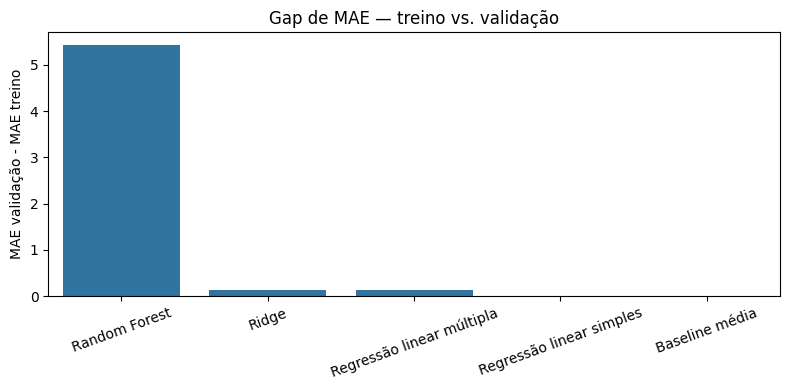

In [15]:
plt.figure(figsize=(8, 4))
plot_q1 = comparacao_q1.dropna(subset=['gap_MAE']).copy()
sns.barplot(data=plot_q1, x='modelo', y='gap_MAE')
plt.title('Gap de MAE — treino vs. validação')
plt.ylabel('MAE validação - MAE treino')
plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

del plot_q1

In [16]:
modelos_aprendidos = list(modelos_regressao)
comparacao_modelos_aprendidos = comparacao_q1.loc[
    comparacao_q1['modelo'].isin(modelos_aprendidos)
].copy()

print('Ranking inicial dos modelos aprendidos por MAE CV:')
display(
    comparacao_modelos_aprendidos[
        ['modelo', 'MAE_CV', 'RMSE_CV', 'R2_CV', 'gap_MAE']
    ].sort_values('MAE_CV')
)

Ranking inicial dos modelos aprendidos por MAE CV:


,modelo,MAE_CV,RMSE_CV,R2_CV,gap_MAE
0,Random Forest,8.580,11.438,0.634,5.433
1,Ridge,9.946,12.720,0.548,0.131
2,Regressão linear múltipla,9.946,12.720,0.548,0.131
3,Regressão linear simples,11.547,14.600,0.404,0.006


## Conclusão parcial — comparação inicial dos modelos de regressão

A tabela anterior é a referência para comparar MAE, RMSE, R² e `gap_MAE` entre baselines e modelos aprendidos, todos avaliados na mesma amostra comparável de 2024.

A Random Forest segue para uma otimização moderada porque combina maior flexibilidade preditiva com hiperparâmetros capazes de regularizar sua complexidade. Os modelos lineares permanecem como referências importantes de estabilidade e simplicidade.

A busca continua sendo otimizada por MAE; o `gap_MAE` é utilizado posteriormente como diagnóstico de sobreajuste. O conjunto de 2025 permanece intocado até o teste temporal final.


### 8.5 Otimização moderada da Random Forest

A busca continua sendo otimizada por MAE, mas inclui hiperparâmetros de regularização destinados a controlar o sobreajuste; o `gap_MAE` é posteriormente utilizado como diagnóstico.

A busca usa exclusivamente 2024. Nenhuma decisão utiliza 2025.


In [17]:
pipeline_rf_reg = modelos_regressao['Random Forest']

parametros_rf_reg = {
    'model__n_estimators': [200, 600],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 10],
    'model__max_features': ['sqrt', 0.5, 0.8],
}

busca_q1 = RandomizedSearchCV(
    estimator=pipeline_rf_reg,
    param_distributions=parametros_rf_reg,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv_regressao,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
busca_q1.fit(X_q1_2024_comum, y_q1_2024_comum)

print('Melhores parâmetros:')
display(pd.Series(busca_q1.best_params_, name='valor').to_frame())
print(f'MAE CV otimizado: {-busca_q1.best_score_:.3f}')

resultados_busca_q1 = pd.DataFrame(busca_q1.cv_results_)
resultados_busca_q1['MAE_CV'] = -resultados_busca_q1['mean_test_score']
resultados_busca_q1['MAE_treino'] = -resultados_busca_q1['mean_train_score']
resultados_busca_q1['gap_MAE'] = resultados_busca_q1['MAE_CV'] - resultados_busca_q1['MAE_treino']

display(
    resultados_busca_q1
    .sort_values('MAE_CV')
    [['MAE_CV','std_test_score','MAE_treino','gap_MAE','params']]
    .head(10)
)

Melhores parâmetros:


,valor
model__n_estimators,200.000
model__min_samples_split,5.000
model__min_samples_leaf,10.000
model__max_features,0.500
model__max_depth,20.000


MAE CV otimizado: 8.483


,MAE_CV,std_test_score,MAE_treino,gap_MAE,params
1,8.483,0.182,6.307,2.176,"{'model__n_estimators': 200, 'model__min_sampl..."
8,8.484,0.183,6.307,2.177,"{'model__n_estimators': 200, 'model__min_sampl..."
19,8.491,0.189,6.604,1.887,"{'model__n_estimators': 600, 'model__min_sampl..."
12,8.494,0.201,3.113,5.381,"{'model__n_estimators': 600, 'model__min_sampl..."
15,8.494,0.180,6.164,2.330,"{'model__n_estimators': 200, 'model__min_sampl..."
16,8.501,0.182,3.198,5.303,"{'model__n_estimators': 200, 'model__min_sampl..."
6,8.512,0.200,3.446,5.066,"{'model__n_estimators': 200, 'model__min_sampl..."
10,8.515,0.180,6.490,2.025,"{'model__n_estimators': 600, 'model__min_sampl..."
13,8.515,0.180,6.490,2.025,"{'model__n_estimators': 600, 'model__min_sampl..."
18,8.515,0.181,5.593,2.922,"{'model__n_estimators': 600, 'model__min_sampl..."


## 8.6 Seleção após a otimização

A célula seguinte compara, por **MAE de cross-validation em 2024**, a Random Forest otimizada com regressão linear simples, regressão linear múltipla e Ridge.

A versão inicial da Random Forest é substituída pela versão otimizada nessa decisão. O modelo com menor MAE CV é selecionado.

Depois da seleção, serão geradas previsões OOF em 2024 para diagnóstico *in-time*. O conjunto de 2025 permanece intocado até o teste temporal final.


In [18]:
mae_candidatos_q1 = {
    nome: comparacao_q1.loc[
        comparacao_q1['modelo'].eq(nome), 'MAE_CV'
    ].iloc[0]
    for nome in modelos_regressao
    if nome != 'Random Forest'
}
mae_candidatos_q1['Random Forest otimizada'] = -busca_q1.best_score_

ranking_final_q1 = (
    pd.Series(mae_candidatos_q1, name='MAE_CV')
    .sort_values()
    .to_frame()
)

display(ranking_final_q1)

NOME_MODELO_Q1_ESCOLHIDO = ranking_final_q1.index[0]

if NOME_MODELO_Q1_ESCOLHIDO == 'Random Forest otimizada':
    MODELO_Q1_ESCOLHIDO = busca_q1.best_estimator_
    PARAMETROS_Q1_ESCOLHIDOS = busca_q1.best_params_
else:
    MODELO_Q1_ESCOLHIDO = clone(
        modelos_regressao[NOME_MODELO_Q1_ESCOLHIDO]
    )
    PARAMETROS_Q1_ESCOLHIDOS = MODELO_Q1_ESCOLHIDO.get_params()

print(
    'Modelo selecionado após CV/tuning em 2024:',
    NOME_MODELO_Q1_ESCOLHIDO,
)
print(f'MAE CV usado na seleção: {ranking_final_q1.iloc[0, 0]:.3f}')

,MAE_CV
Random Forest otimizada,8.483
Ridge,9.946
Regressão linear múltipla,9.946
Regressão linear simples,11.547


Modelo selecionado após CV/tuning em 2024: Random Forest otimizada
MAE CV usado na seleção: 8.483


## 8.7 Diagnóstico out-of-fold (OOF) em 2024

Com o modelo e os hiperparâmetros já selecionados, são geradas previsões **out-of-fold** usando os mesmos 5 folds de 2024.

Cada município é previsto por uma cópia do modelo treinada nos outros folds, de modo que a previsão daquele município é produzida sem que sua própria observação tenha participado do ajuste correspondente.

As métricas OOF são usadas como **diagnóstico de desenvolvimento/in-time**. Como a escolha do modelo foi feita usando 2024, elas não devem ser interpretadas como um teste final independente; essa função pertence ao teste temporal de 2025.

A comparação com `taxa_lag1` usa exatamente os mesmos municípios.


In [19]:
pred_oof_q1_2024 = cross_val_predict(
    MODELO_Q1_ESCOLHIDO,
    X_q1_2024_comum,
    y_q1_2024_comum,
    cv=cv_regressao,
    n_jobs=-1,
)

comparacao_oof_q1_2024 = pd.DataFrame({
    NOME_MODELO_Q1_ESCOLHIDO: metricas_regressao(
        y_q1_2024_comum,
        pred_oof_q1_2024,
    ),
    'Baseline taxa_lag1': metricas_regressao(
        y_q1_2024_comum,
        pred_baseline_lag1_2024,
    ),
}).T

comparacao_oof_q1_2024['ganho_MAE_vs_baseline'] = (
    comparacao_oof_q1_2024.loc['Baseline taxa_lag1', 'MAE']
    - comparacao_oof_q1_2024['MAE']
)

comparacao_oof_q1_2024['ganho_MAE_vs_baseline_pct'] = (
    comparacao_oof_q1_2024['ganho_MAE_vs_baseline']
    / comparacao_oof_q1_2024.loc['Baseline taxa_lag1', 'MAE']
    * 100
)

print(f'Previsões OOF geradas para {len(pred_oof_q1_2024):,} municípios de 2024.')
display(comparacao_oof_q1_2024)


Previsões OOF geradas para 5,416 municípios de 2024.


,MAE,RMSE,R2,ganho_MAE_vs_baseline,ganho_MAE_vs_baseline_pct
Random Forest otimizada,8.483,11.316,0.643,4.023,32.170
Baseline taxa_lag1,12.506,16.789,0.214,0.000,0.000


### Observado versus previsto — OOF de 2024

O gráfico abaixo compara `taxa_realizada` com a previsão OOF de cada município.

- pontos próximos à diagonal indicam previsões mais próximas do observado;
- pontos acima da diagonal representam superestimação;
- pontos abaixo representam subestimação.

Esse gráfico descreve o comportamento do modelo durante o desenvolvimento em 2024; o teste temporal independente continua sendo 2025.


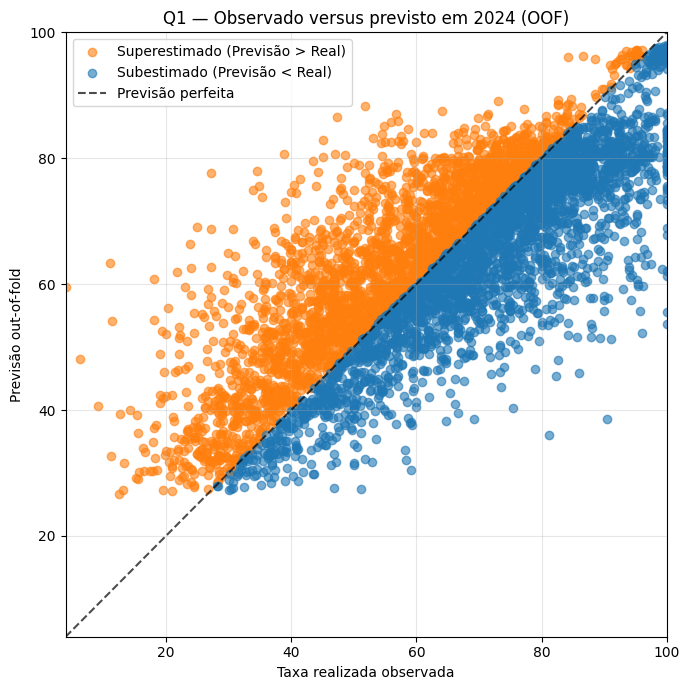

In [34]:
observado_previsto_q1_2024 = pd.DataFrame({
    'taxa_realizada': y_q1_2024_comum.to_numpy(),
    'previsao': pred_oof_q1_2024,
})

limite_inferior = min(
    observado_previsto_q1_2024['taxa_realizada'].min(),
    observado_previsto_q1_2024['previsao'].min(),
)
limite_superior = max(
    observado_previsto_q1_2024['taxa_realizada'].max(),
    observado_previsto_q1_2024['previsao'].max(),
)

mask_exato = np.isclose(
    observado_previsto_q1_2024['previsao'],
    observado_previsto_q1_2024['taxa_realizada'],
    atol=0.01,
)
mask_superestimou = (
    observado_previsto_q1_2024['previsao']
    > observado_previsto_q1_2024['taxa_realizada']
) & ~mask_exato
mask_subestimou = (
    observado_previsto_q1_2024['previsao']
    < observado_previsto_q1_2024['taxa_realizada']
) & ~mask_exato

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    observado_previsto_q1_2024.loc[mask_superestimou, 'taxa_realizada'],
    observado_previsto_q1_2024.loc[mask_superestimou, 'previsao'],
    alpha=0.6,
    color='tab:orange',
    label='Superestimado (Previsão > Real)',
)

ax.scatter(
    observado_previsto_q1_2024.loc[mask_subestimou, 'taxa_realizada'],
    observado_previsto_q1_2024.loc[mask_subestimou, 'previsao'],
    alpha=0.6,
    color='tab:blue',
    label='Subestimado (Previsão < Real)',
)


ax.plot(
    [limite_inferior, limite_superior],
    [limite_inferior, limite_superior],
    linestyle='--',
    color='black',
    alpha=0.7,
    label='Previsão perfeita',
)

ax.set_title('Q1 — Observado versus previsto em 2024 (OOF)')
ax.set_xlabel('Taxa realizada observada')
ax.set_ylabel('Previsão out-of-fold')
ax.set_xlim(limite_inferior, limite_superior)
ax.set_ylim(limite_inferior, limite_superior)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 8.8 Ajuste final em 2024 e teste temporal em 2025

Neste ponto, todas as decisões de desenvolvimento do Q1 foram tomadas usando somente 2024.

O modelo selecionado pelo menor MAE de cross-validation é ajustado novamente com **100% dos registros válidos de 2024** e avaliado uma única vez em 2025.

O resultado de 2025 é o **teste temporal final (out-of-time)** e não será usado para alterar modelo ou hiperparâmetros.


In [21]:
MODELO_Q1_ESCOLHIDO.fit(X_q1_2024, y_q1_2024)

pred_q1_2025 = MODELO_Q1_ESCOLHIDO.predict(X_q1_2025)

metricas_q1_2025 = pd.Series({
    'MAE_2025': mean_absolute_error(y_q1_2025, pred_q1_2025),
    'RMSE_2025': mean_squared_error(y_q1_2025, pred_q1_2025) ** 0.5,
    'R2_2025': r2_score(y_q1_2025, pred_q1_2025),
}, name='valor')

display(metricas_q1_2025.to_frame())


,valor
MAE_2025,10.375
RMSE_2025,13.075
R2_2025,0.311


## 8.9 Observado versus previsto em 2025

O gráfico abaixo compara o valor **observado** da `taxa_realizada` com a **previsão** do modelo no teste temporal de 2025.

**Mensagem de negócio:** mostra quão próximo o modelo permanece do resultado real quando aplicado a um período posterior ao desenvolvimento.


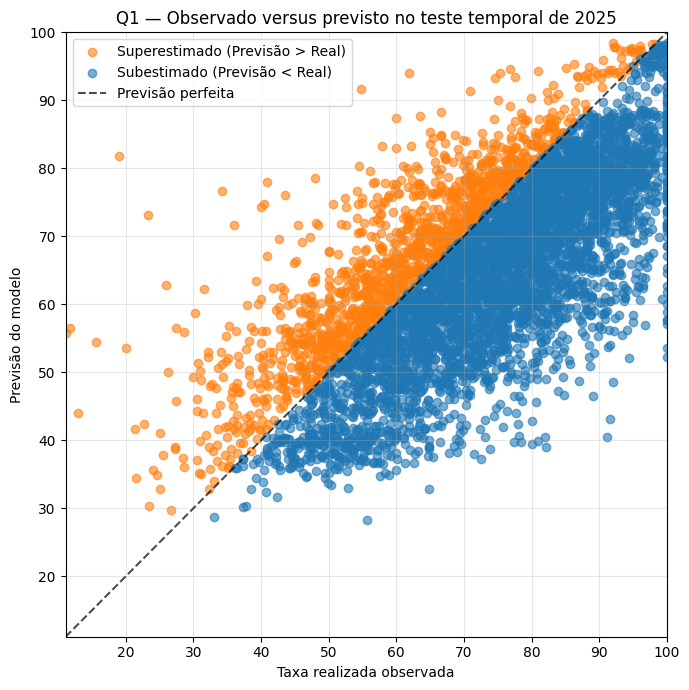

In [33]:
observado_previsto_q1_2025 = pd.DataFrame({
    'taxa_realizada': y_q1_2025.to_numpy(),
    'previsao': pred_q1_2025,
})

limite_inferior = min(
    observado_previsto_q1_2025['taxa_realizada'].min(),
    observado_previsto_q1_2025['previsao'].min(),
)
limite_superior = max(
    observado_previsto_q1_2025['taxa_realizada'].max(),
    observado_previsto_q1_2025['previsao'].max(),
)

mask_exato = np.isclose(
    observado_previsto_q1_2025['previsao'],
    observado_previsto_q1_2025['taxa_realizada'],
    atol=0.01,
)
mask_superestimou = (
    observado_previsto_q1_2025['previsao']
    > observado_previsto_q1_2025['taxa_realizada']
) & ~mask_exato
mask_subestimou = (
    observado_previsto_q1_2025['previsao']
    < observado_previsto_q1_2025['taxa_realizada']
) & ~mask_exato

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    observado_previsto_q1_2025.loc[mask_superestimou, 'taxa_realizada'],
    observado_previsto_q1_2025.loc[mask_superestimou, 'previsao'],
    alpha=0.6,
    color='tab:orange',
    label='Superestimado (Previsão > Real)',
)

ax.scatter(
    observado_previsto_q1_2025.loc[mask_subestimou, 'taxa_realizada'],
    observado_previsto_q1_2025.loc[mask_subestimou, 'previsao'],
    alpha=0.6,
    color='tab:blue',
    label='Subestimado (Previsão < Real)',
)


ax.plot(
    [limite_inferior, limite_superior],
    [limite_inferior, limite_superior],
    linestyle='--',
    color='black',
    alpha=0.7,
    label='Previsão perfeita',
)

ax.set_title('Q1 — Observado versus previsto no teste temporal de 2025')
ax.set_xlabel('Taxa realizada observada')
ax.set_ylabel('Previsão do modelo')
ax.set_xlim(limite_inferior, limite_superior)
ax.set_ylim(limite_inferior, limite_superior)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 8.10 Comparação temporal com o baseline `taxa_lag1`

Para verificar se o modelo ainda acrescenta informação útil em um período futuro, ele é comparado com o baseline simples `taxa_lag1` **nas mesmas observações de 2025**.

A lógica do baseline é usar a taxa anterior como previsão da taxa atual. Assim, a comparação mostra se o modelo oferece ganho preditivo além da persistência temporal.

A comparação é apenas diagnóstica. **2025 não é usado para retunar hiperparâmetros ou trocar o modelo selecionado em 2024.**


In [23]:
# Baseline temporal: prever 2025 usando diretamente taxa_lag1.
# Modelo e baseline são avaliados nas mesmas observações.

if 'taxa_lag1' not in X_q1_2025.columns:
    raise KeyError("A análise adicional requer a feature 'taxa_lag1'.")

mascara_baseline_2025 = X_q1_2025['taxa_lag1'].notna()

if not mascara_baseline_2025.any():
    raise ValueError("Não há valores válidos de 'taxa_lag1' no conjunto de teste de 2025.")

y_q1_2025_comum = y_q1_2025.loc[mascara_baseline_2025]
pred_modelo_2025_comum = pred_q1_2025[mascara_baseline_2025.to_numpy()]
pred_baseline_lag1_2025 = (
    X_q1_2025.loc[mascara_baseline_2025, 'taxa_lag1'].to_numpy()
)

comparacao_temporal_q1 = pd.DataFrame({
    NOME_MODELO_Q1_ESCOLHIDO: metricas_regressao(
        y_q1_2025_comum,
        pred_modelo_2025_comum,
    ),
    'Baseline taxa_lag1': metricas_regressao(
        y_q1_2025_comum,
        pred_baseline_lag1_2025,
    ),
}).T

comparacao_temporal_q1['ganho_MAE_vs_baseline'] = (
    comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE']
    - comparacao_temporal_q1['MAE']
)

comparacao_temporal_q1['ganho_MAE_vs_baseline_pct'] = (
    comparacao_temporal_q1['ganho_MAE_vs_baseline']
    / comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE']
    * 100
)

comparacao_erros_q1 = pd.DataFrame({
    'erro_abs_baseline': np.abs(
        y_q1_2025_comum.to_numpy() - pred_baseline_lag1_2025
    ),
    'erro_abs_modelo': np.abs(
        y_q1_2025_comum.to_numpy() - pred_modelo_2025_comum
    ),
})

print(
    f'Observações comparáveis em 2025: {mascara_baseline_2025.sum():,} '
    f'de {len(X_q1_2025):,}'
)
display(comparacao_temporal_q1)


Observações comparáveis em 2025: 5,438 de 5,553


,MAE,RMSE,R2,ganho_MAE_vs_baseline,ganho_MAE_vs_baseline_pct
Random Forest otimizada,10.333,13.021,0.310,2.740,20.958
Baseline taxa_lag1,13.072,17.058,-0.185,0.000,0.000


## 8.11 Ganho do modelo sobre o baseline por município em 2025

Cada ponto representa um município:

- abaixo da diagonal: o modelo teve erro absoluto menor que `taxa_lag1`;
- acima da diagonal: o baseline teve erro absoluto menor;
- sobre a diagonal: desempenho equivalente.

Esse diagnóstico mostra se o ganho agregado em MAE também aparece de forma disseminada entre os municípios.


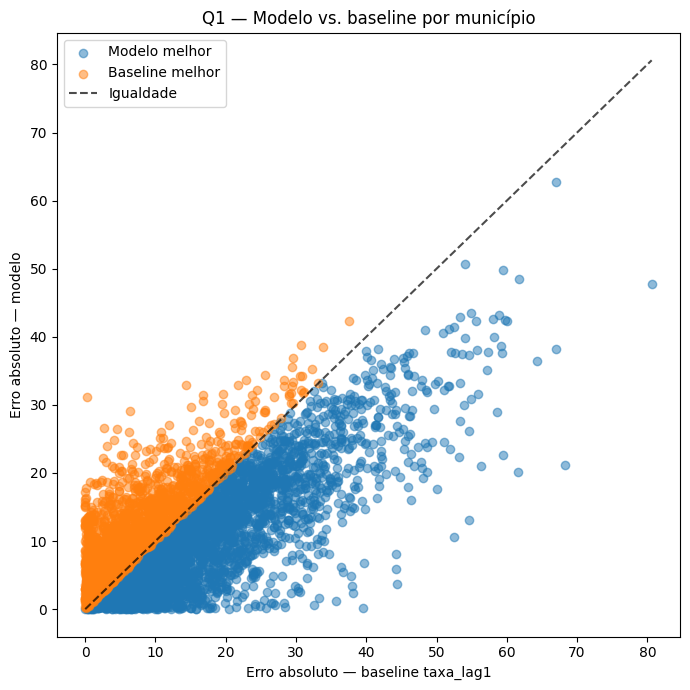

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

limite = max(
    comparacao_erros_q1['erro_abs_baseline'].max(),
    comparacao_erros_q1['erro_abs_modelo'].max(),
)

fig, ax = plt.subplots(figsize=(7, 7))

# Criando máscaras para separar quem está abaixo (modelo melhor) e acima (baseline melhor)
mask_modelo_melhor = comparacao_erros_q1['erro_abs_modelo'] < comparacao_erros_q1['erro_abs_baseline']
mask_baseline_melhor = comparacao_erros_q1['erro_abs_modelo'] > comparacao_erros_q1['erro_abs_baseline']
mask_empate = comparacao_erros_q1['erro_abs_modelo'] == comparacao_erros_q1['erro_abs_baseline']

# Plota os pontos onde o modelo é melhor (abaixo da linha)
ax.scatter(
    comparacao_erros_q1.loc[mask_modelo_melhor, 'erro_abs_baseline'],
    comparacao_erros_q1.loc[mask_modelo_melhor, 'erro_abs_modelo'],
    alpha=0.5,
    color='tab:blue',
    label='Modelo melhor',
)

# Plota os pontos onde a baseline é melhor (acima da linha)
ax.scatter(
    comparacao_erros_q1.loc[mask_baseline_melhor, 'erro_abs_baseline'],
    comparacao_erros_q1.loc[mask_baseline_melhor, 'erro_abs_modelo'],
    alpha=0.5,
    color='tab:orange',
    label='Baseline melhor',
)

# Plota empates (se houver)
if mask_empate.any():
    ax.scatter(
        comparacao_erros_q1.loc[mask_empate, 'erro_abs_baseline'],
        comparacao_erros_q1.loc[mask_empate, 'erro_abs_modelo'],
        alpha=0.5,
        color='tab:gray',
        label='Empate',
    )

# Linha de igualdade (y = x)
ax.plot(
    [0, limite],
    [0, limite],
    linestyle='--',
    color='black',
    alpha=0.7,
    label='Igualdade',
)

ax.set_xlabel('Erro absoluto — baseline taxa_lag1')
ax.set_ylabel('Erro absoluto — modelo')
ax.set_title('Q1 — Modelo vs. baseline por município')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [25]:
modelo_melhor = (
    comparacao_erros_q1['erro_abs_modelo']
    < comparacao_erros_q1['erro_abs_baseline']
)

baseline_melhor = (
    comparacao_erros_q1['erro_abs_modelo']
    > comparacao_erros_q1['erro_abs_baseline']
)

empate = (
    comparacao_erros_q1['erro_abs_modelo']
    == comparacao_erros_q1['erro_abs_baseline']
)

print(
    f'Modelo melhor: {modelo_melhor.mean()*100:.1f}%'
)
print(
    f'Baseline melhor: {baseline_melhor.mean()*100:.1f}%'
)
print(
    f'Empate: {empate.mean()*100:.1f}%'
)

Modelo melhor: 62.4%
Baseline melhor: 37.6%
Empate: 0.0%


## 8.12 Comparação visual do MAE — OOF 2024 e teste temporal 2025

O gráfico reúne duas comparações em amostras equivalentes:

- **2024:** previsão OOF do modelo versus baseline `taxa_lag1`;
- **2025:** teste temporal do modelo versus baseline `taxa_lag1`.

**Mensagem de negócio:** permite visualizar a capacidade do modelo de superar a persistência histórica durante o desenvolvimento e, principalmente, no período futuro.


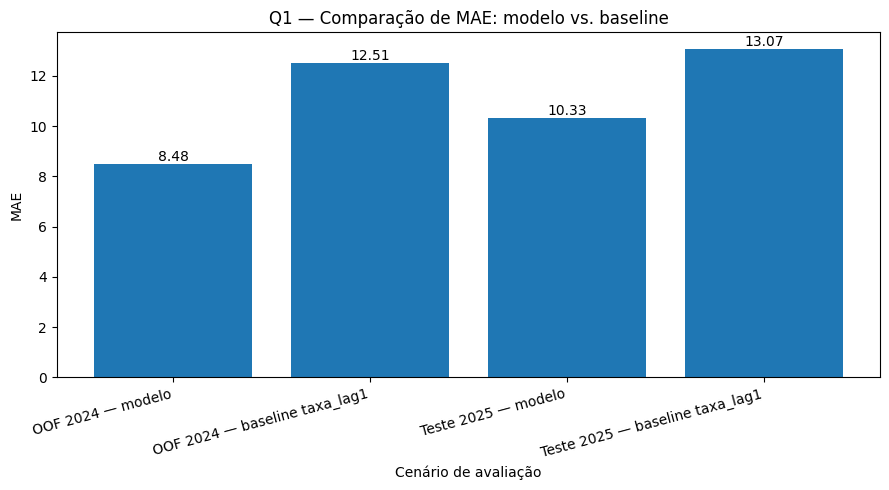

,cenario,MAE
0,OOF 2024 — modelo,8.483
1,OOF 2024 — baseline taxa_lag1,12.506
2,Teste 2025 — modelo,10.333
3,Teste 2025 — baseline taxa_lag1,13.072


In [26]:
comparacao_mae_q1 = pd.DataFrame({
    'cenario': [
        'OOF 2024 — modelo',
        'OOF 2024 — baseline taxa_lag1',
        'Teste 2025 — modelo',
        'Teste 2025 — baseline taxa_lag1',
    ],
    'MAE': [
        comparacao_oof_q1_2024.loc[NOME_MODELO_Q1_ESCOLHIDO, 'MAE'],
        comparacao_oof_q1_2024.loc['Baseline taxa_lag1', 'MAE'],
        comparacao_temporal_q1.loc[NOME_MODELO_Q1_ESCOLHIDO, 'MAE'],
        comparacao_temporal_q1.loc['Baseline taxa_lag1', 'MAE'],
    ],
})

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(
    comparacao_mae_q1['cenario'],
    comparacao_mae_q1['MAE'],
)
ax.set_title('Q1 — Comparação de MAE: modelo vs. baseline')
ax.set_xlabel('Cenário de avaliação')
ax.set_ylabel('MAE')
ax.bar_label(barras, fmt='%.2f')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

display(comparacao_mae_q1)


## 8.13 Conclusão parcial — desenvolvimento OOF e desempenho temporal

A avaliação de Q1 possui dois níveis complementares:

1. **OOF 2024:** diagnóstico *in-time* do modelo selecionado, produzido sem reservar um holdout fixo;
2. **2025:** teste temporal final, realizado somente após o encerramento das decisões de desenvolvimento.

As previsões OOF não constituem um teste externo independente, pois o modelo e seus hiperparâmetros foram escolhidos usando 2024. A evidência mais forte de generalização continua sendo o desempenho em 2025.

A comparação com `taxa_lag1` é feita nas mesmas observações de cada período, permitindo medir o ganho sobre uma regra simples de persistência.


## 8.14 Análise inicial dos erros no teste temporal

A tabela abaixo mantém os identificadores fora das features e os utiliza somente para localizar os municípios com maiores erros absolutos em 2025.


In [27]:
erros_q1_2025 = chaves_q1_2025.copy()

# Recupera o nome do município mantendo exatamente o mesmo alinhamento de índices.
erros_q1_2025['nome_municipio'] = (
    DADOS_TESTE_FINAL
    .loc[erros_q1_2025.index, 'nome_municipio']
    .to_numpy()
)

# Sigla da UF a partir do código IBGE.
mapa_siglas_uf = {
    11: 'RO',
    12: 'AC',
    13: 'AM',
    14: 'RR',
    15: 'PA',
    16: 'AP',
    17: 'TO',
    21: 'MA',
    22: 'PI',
    23: 'CE',
    24: 'RN',
    25: 'PB',
    26: 'PE',
    27: 'AL',
    28: 'SE',
    29: 'BA',
    31: 'MG',
    32: 'ES',
    33: 'RJ',
    35: 'SP',
    41: 'PR',
    42: 'SC',
    43: 'RS',
    50: 'MS',
    51: 'MT',
    52: 'GO',
    53: 'DF',
}

erros_q1_2025['uf'] = (
    erros_q1_2025['id_uf']
    .astype('Int64')
    .map(mapa_siglas_uf)
)

erros_q1_2025['taxa_realizada'] = y_q1_2025.to_numpy()
erros_q1_2025['previsao'] = pred_q1_2025
erros_q1_2025['erro'] = (
    erros_q1_2025['taxa_realizada']
    - erros_q1_2025['previsao']
)
erros_q1_2025['erro_absoluto'] = erros_q1_2025['erro'].abs()

colunas_exibicao = [
    'id_municipio',
    'nome_municipio',
    'id_uf',
    'uf',
    'taxa_realizada',
    'previsao',
    'erro',
    'erro_absoluto',
]

display(
    erros_q1_2025
    .sort_values('erro_absoluto', ascending=False)
    [colunas_exibicao]
    .head(20)
)

,id_municipio,nome_municipio,id_uf,uf,taxa_realizada,previsao,erro,erro_absoluto
8088,3129103,Gurinhatã,31,MG,19.048,81.819,-62.771,62.771
5802,1508035,Tracuateua,15,PA,91.204,40.550,50.654,50.654
6863,2508406,Lastro,25,PB,23.333,73.155,-49.822,49.822
7543,2916906,Itiruçu,29,BA,91.667,43.181,48.486,48.486
6316,2206654,Morro Cabeça no Tempo,22,PI,100.000,52.178,47.822,47.822
10305,4309571,Herveiras,43,RS,100.000,53.547,46.453,46.453
10220,4305371,Charrua,43,RS,11.765,56.518,-44.753,44.753
10333,4310876,Jacuizinho,43,RS,11.111,55.826,-44.715,44.715
7349,2900504,Érico Cardoso,29,BA,92.105,48.566,43.539,43.539
7476,2910909,Firmino Alves,29,BA,82.143,38.943,43.200,43.200


## 8.15 Erros médios por UF no teste temporal de 2025

A análise a seguir agrega o erro absoluto por **UF**, ordenando os territórios do maior para o menor MAE médio.

**Mensagem de negócio:** identifica onde o modelo é mais ou menos confiável para apoiar decisões territoriais.


,id_uf,sigla_uf,regiao,MAE_medio
0,11,RO,Norte,17.670
1,12,AC,Norte,16.681
2,25,PB,Nordeste,16.361
3,29,BA,Nordeste,15.818
4,13,AM,Norte,13.331
5,43,RS,Sul,12.852
6,27,AL,Nordeste,12.818
7,17,TO,Norte,12.523
8,15,PA,Norte,12.442
9,21,MA,Nordeste,11.574


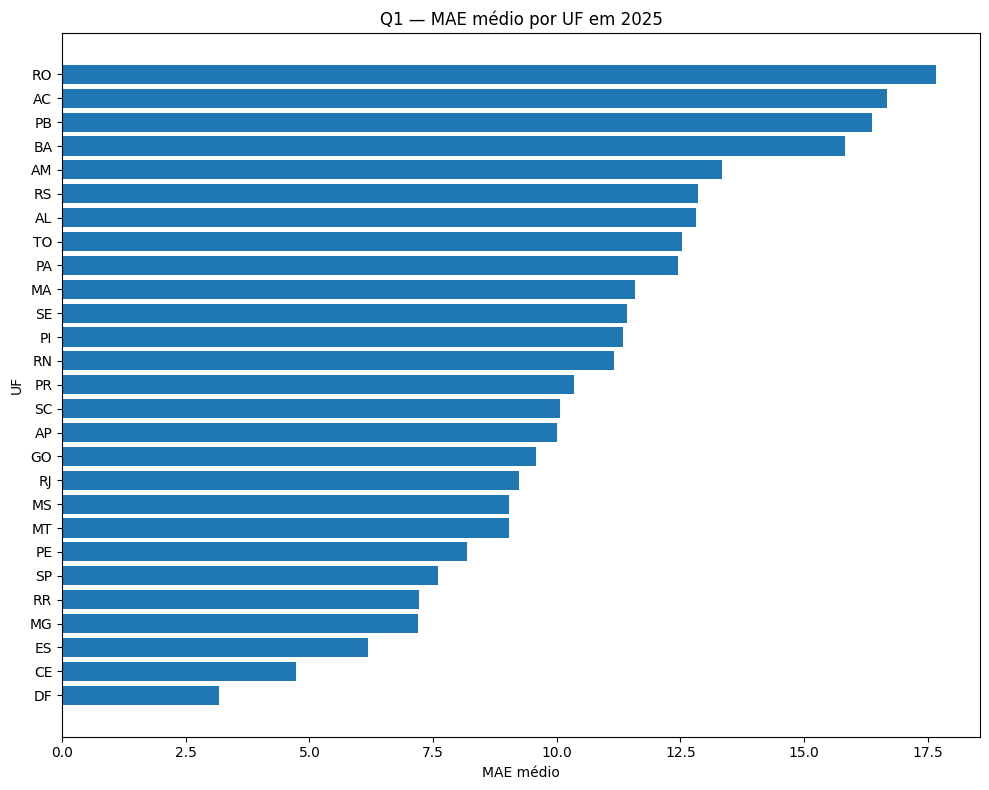

In [28]:
mapa_ufs = {
    11: ('RO', 'Norte'),
    12: ('AC', 'Norte'),
    13: ('AM', 'Norte'),
    14: ('RR', 'Norte'),
    15: ('PA', 'Norte'),
    16: ('AP', 'Norte'),
    17: ('TO', 'Norte'),
    21: ('MA', 'Nordeste'),
    22: ('PI', 'Nordeste'),
    23: ('CE', 'Nordeste'),
    24: ('RN', 'Nordeste'),
    25: ('PB', 'Nordeste'),
    26: ('PE', 'Nordeste'),
    27: ('AL', 'Nordeste'),
    28: ('SE', 'Nordeste'),
    29: ('BA', 'Nordeste'),
    31: ('MG', 'Sudeste'),
    32: ('ES', 'Sudeste'),
    33: ('RJ', 'Sudeste'),
    35: ('SP', 'Sudeste'),
    41: ('PR', 'Sul'),
    42: ('SC', 'Sul'),
    43: ('RS', 'Sul'),
    50: ('MS', 'Centro-Oeste'),
    51: ('MT', 'Centro-Oeste'),
    52: ('GO', 'Centro-Oeste'),
    53: ('DF', 'Centro-Oeste'),
}

erros_q1_2025_uf = erros_q1_2025.copy()
erros_q1_2025_uf['sigla_uf'] = erros_q1_2025_uf['id_uf'].map(
    lambda x: mapa_ufs.get(int(x), (str(x), 'Não identificada'))[0]
    if pd.notna(x) else 'NA'
)
erros_q1_2025_uf['regiao'] = erros_q1_2025_uf['id_uf'].map(
    lambda x: mapa_ufs.get(int(x), ('NA', 'Não identificada'))[1]
    if pd.notna(x) else 'Não identificada'
)

mae_por_uf_q1 = (
    erros_q1_2025_uf
    .groupby(['id_uf', 'sigla_uf', 'regiao'], as_index=False)['erro_absoluto']
    .mean()
    .rename(columns={'erro_absoluto': 'MAE_medio'})
    .sort_values('MAE_medio', ascending=False)
    .reset_index(drop=True)
)

display(mae_por_uf_q1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(mae_por_uf_q1['sigla_uf'], mae_por_uf_q1['MAE_medio'])
ax.set_title('Q1 — MAE médio por UF em 2025')
ax.set_xlabel('MAE médio')
ax.set_ylabel('UF')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 8.16 Permutation Importance — importância global simples

A Permutation Importance responde a uma pergunta intuitiva:

> **Quanto o modelo piora quando embaralhamos uma variável e destruímos a informação que ela carregava?**

A métrica usada continua sendo o **MAE**. Assim, valores maiores de `aumento_MAE_ao_embaralhar` indicam variáveis mais importantes para o poder preditivo do modelo em 2025.

A análise é feita diretamente nas features originais de `X_q1_2025`, de forma que o ranking permaneça fácil de relacionar com as variáveis da base.


,variavel,aumento_MAE_ao_embaralhar,desvio_padrao
0,proficiencia_lag1,1.061,0.053
1,ctx_inep_uf_percentual_participacao_lag1,0.456,0.029
2,ctx_inep_uf_media_portugues_lag1,0.415,0.032
3,taxa_lag1,0.407,0.029
4,participacao_lag1,0.191,0.023
5,ctx_atlas_taxa_densidade_domiciliar,0.068,0.013
6,ctx_ibge_renda_domiciliar_per_capita_media,0.041,0.003
7,ctx_atlas_idhm_longevidade,0.028,0.001
8,ctx_atlas_taxa_trabalho_infantil_10a14,0.025,0.003
9,ctx_atlas_taxa_fora_escola_4a5,0.021,0.004


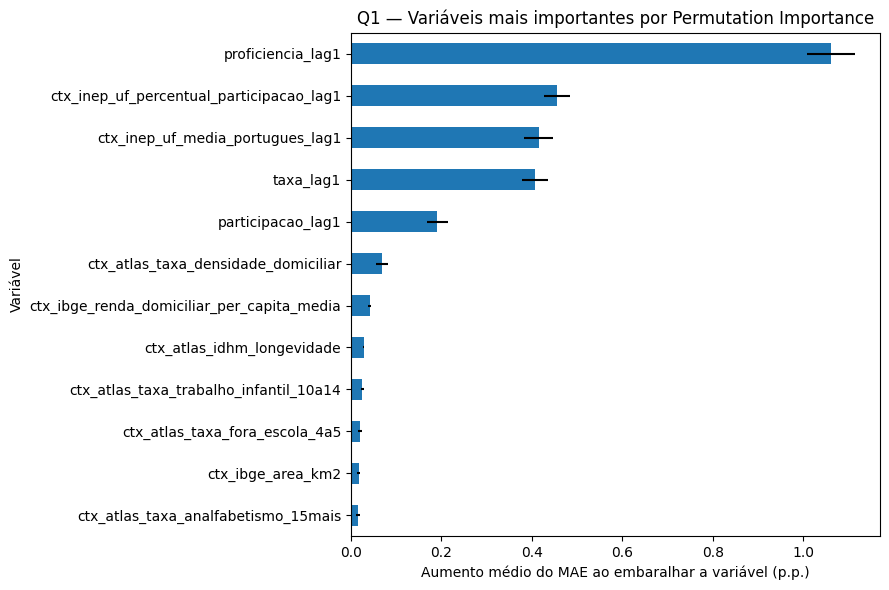

In [29]:
# Permutation Importance no teste temporal de 2025.
# scoring='neg_mean_absolute_error': a importância positiva representa
# quanto o MAE piora, em média, quando a variável é embaralhada.

resultado_perm_q1 = permutation_importance(
    MODELO_Q1_ESCOLHIDO,
    X_q1_2025,
    y_q1_2025,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importancia_perm_q1 = (
    pd.DataFrame({
        'variavel': X_q1_2025.columns,
        'aumento_MAE_ao_embaralhar': resultado_perm_q1.importances_mean,
        'desvio_padrao': resultado_perm_q1.importances_std,
    })
    .sort_values('aumento_MAE_ao_embaralhar', ascending=False)
    .reset_index(drop=True)
)

display(importancia_perm_q1.head(15))

top_perm = importancia_perm_q1.head(12).sort_values('aumento_MAE_ao_embaralhar')
ax = top_perm.plot.barh(
    x='variavel',
    y='aumento_MAE_ao_embaralhar',
    xerr='desvio_padrao',
    legend=False,
    figsize=(9, 6),
)
ax.set_title('Q1 — Variáveis mais importantes por Permutation Importance')
ax.set_xlabel('Aumento médio do MAE ao embaralhar a variável (p.p.)')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()


### Leitura da Permutation Importance

- Quanto maior o aumento do MAE após o embaralhamento, maior a dependência do modelo daquela variável.
- Valores próximos de zero sugerem pouca contribuição adicional para a previsão, considerando as demais features.
- Importâncias negativas podem ocorrer por ruído/amostragem e não devem ser interpretadas como efeito protetor.
- Variáveis correlacionadas podem dividir importância entre si; portanto, o ranking não deve ser interpretado como uma medida causal nem como efeito isolado.


## 8.17 SHAP global — aprofundamento da interpretação

O SHAP complementa a Permutation Importance. Aqui o objetivo é medir a **magnitude média da contribuição de cada variável para as previsões** da Random Forest.

Para manter a análise simples, eventuais colunas criadas pelo pré-processamento — por exemplo, dummies de uma variável categórica — são **agregadas novamente à variável de origem** no ranking final.

A análise usa uma amostra reprodutível de até 1.000 municípios de 2025 para tornar o cálculo mais leve. Isso é suficiente para uma interpretação global exploratória, sem alterar o modelo treinado.


,variavel,media_abs_SHAP
0,proficiencia_lag1,4.723
1,ctx_inep_uf_media_portugues_lag1,3.914
2,taxa_lag1,2.454
3,ctx_inep_uf_percentual_participacao_lag1,2.010
4,participacao_lag1,0.979
5,ctx_atlas_taxa_densidade_domiciliar,0.850
6,ctx_fundeb_nse_uf,0.728
7,ctx_atlas_taxa_analfabetismo_11a14,0.512
8,populacao,0.323
9,ctx_atlas_taxa_fora_escola_4a5,0.252


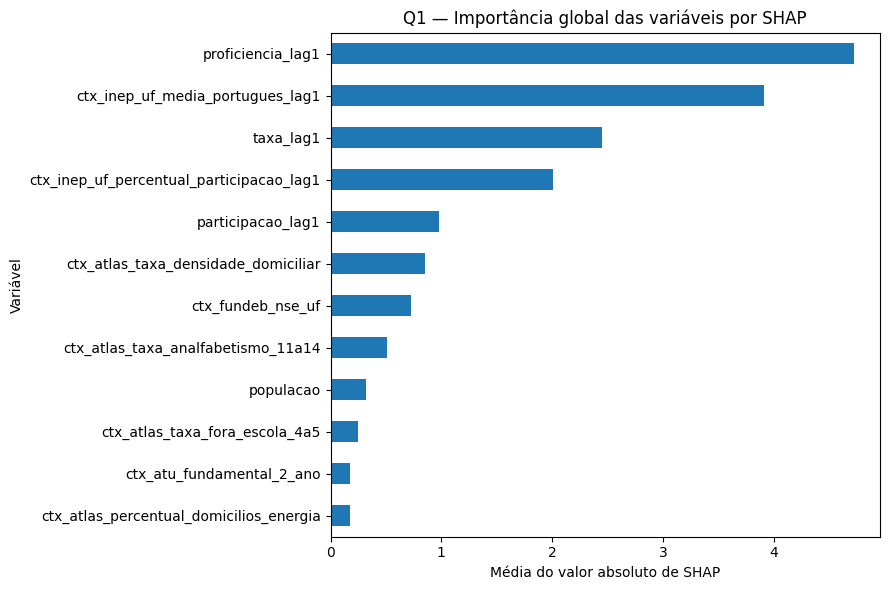

In [30]:
# SHAP global da Random Forest escolhida.
# O código usa o pré-processamento já ajustado dentro do Pipeline.

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "A biblioteca 'shap' não está disponível neste ambiente. "
        "No Colab, instale-a antes desta célula com: %pip install -q shap"
    ) from exc

if 'model' not in MODELO_Q1_ESCOLHIDO.named_steps:
    raise ValueError('O pipeline escolhido não possui a etapa model esperada.')

modelo_final_q1 = MODELO_Q1_ESCOLHIDO.named_steps['model']
preprocessor_final_q1 = MODELO_Q1_ESCOLHIDO.named_steps['preprocessor']

# Reproduz somente a transformação já aprendida pelo pipeline.
if 'features' in MODELO_Q1_ESCOLHIDO.named_steps:
    X_q1_2025_eng = MODELO_Q1_ESCOLHIDO.named_steps['features'].transform(X_q1_2025)
else:
    X_q1_2025_eng = X_q1_2025.copy()

n_shap = min(1000, len(X_q1_2025_eng))
idx_shap = X_q1_2025_eng.sample(
    n=n_shap,
    random_state=RANDOM_STATE,
).index

X_shap_eng = X_q1_2025_eng.loc[idx_shap]
X_shap_trans = preprocessor_final_q1.transform(X_shap_eng)
nomes_transformados = preprocessor_final_q1.get_feature_names_out()

explainer_q1 = shap.TreeExplainer(modelo_final_q1)
shap_exp_q1 = explainer_q1(X_shap_trans)

valores_shap = np.asarray(shap_exp_q1.values)
media_abs_shap = np.abs(valores_shap).mean(axis=0)

# Mapeia colunas transformadas de volta à variável original/engenheirada.
variaveis_origem = list(X_q1_2025_eng.columns)

def identificar_variavel_origem(nome_transformado):
    nome_limpo = str(nome_transformado).split('__', 1)[-1]
    nome_limpo = nome_limpo.replace('missingindicator_', '')
    candidatos = sorted(variaveis_origem, key=len, reverse=True)
    for variavel in candidatos:
        if nome_limpo == variavel or nome_limpo.startswith(f'{variavel}_'):
            return variavel
    return nome_limpo

importancia_shap_transformada_q1 = pd.DataFrame({
    'feature_transformada': nomes_transformados,
    'variavel': [identificar_variavel_origem(x) for x in nomes_transformados],
    'media_abs_SHAP': media_abs_shap,
})

importancia_shap_q1 = (
    importancia_shap_transformada_q1
    .groupby('variavel', as_index=False)['media_abs_SHAP']
    .sum()
    .sort_values('media_abs_SHAP', ascending=False)
    .reset_index(drop=True)
)

display(importancia_shap_q1.head(15))

top_shap = importancia_shap_q1.head(12).sort_values('media_abs_SHAP')
ax = top_shap.plot.barh(
    x='variavel',
    y='media_abs_SHAP',
    legend=False,
    figsize=(9, 6),
)
ax.set_title('Q1 — Importância global das variáveis por SHAP')
ax.set_xlabel('Média do valor absoluto de SHAP')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()


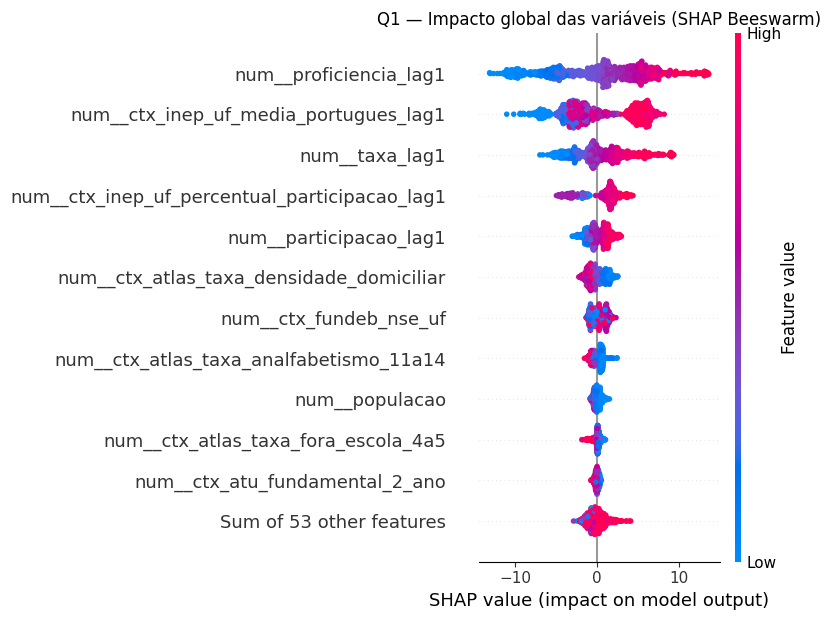

In [31]:
# 1. Garanta que o objeto SHAP tenha os nomes das features corretos
shap_exp_q1.feature_names = list(nomes_transformados)

# 2. Ajuste o tamanho da figura (opcional, para não ficar espremido)
plt.figure(figsize=(9, 6))

# 3. Gere o gráfico beeswarm (o formato de enxame/violino da sua imagem)
shap.plots.beeswarm(
    shap_exp_q1,
    max_display=12,  # Limita para mostrar apenas as 12 variáveis mais importantes (como o seu head(12))
    show=False       # Permite customizar o plot com matplotlib antes de exibi-lo
)

plt.title('Q1 — Impacto global das variáveis (SHAP Beeswarm)')
plt.tight_layout()
plt.show()

## 8.18 Síntese — resposta à Q1

A pergunta de negócio é:

> **Quais fatores mais impactam a alfabetização?**

Neste estudo, a resposta é construída pela convergência entre dois métodos de interpretabilidade:

- **Permutation Importance:** mede quanto o erro aumenta quando a informação de uma variável é destruída;
- **SHAP global:** mede a magnitude média da contribuição de cada variável para as previsões.

Como ambos foram aplicados ao modelo que superou o baseline no teste temporal, os rankings abaixo permitem identificar os fatores com maior **importância/poder preditivo** para a alfabetização futura.


In [32]:
# Consolidação dos resultados de interpretabilidade da Q1.

ranking_perm_q1 = importancia_perm_q1[['variavel', 'aumento_MAE_ao_embaralhar']].copy()
ranking_perm_q1['rank_permutation'] = np.arange(1, len(ranking_perm_q1) + 1)

ranking_shap_q1 = importancia_shap_q1[['variavel', 'media_abs_SHAP']].copy()
ranking_shap_q1['rank_SHAP'] = np.arange(1, len(ranking_shap_q1) + 1)

sintese_importancia_q1 = (
    ranking_perm_q1
    .merge(ranking_shap_q1, on='variavel', how='outer')
    .sort_values(['rank_permutation', 'rank_SHAP'], na_position='last')
    .reset_index(drop=True)
)

display(sintese_importancia_q1.head(15))

top5_perm = ranking_perm_q1.head(5)['variavel'].tolist()
top5_shap = ranking_shap_q1.head(5)['variavel'].tolist()
convergentes = [v for v in top5_perm if v in top5_shap]

print('RESPOSTA À Q1 — Quais fatores mais impactam a alfabetização?')
print('-' * 68)
print(
    'Neste estudo, impacto significa importância ou poder preditivo para a '
    'alfabetização futura; não representa efeito causal.'
)
print('\nTop 5 — Permutation Importance:')
for i, v in enumerate(top5_perm, 1):
    print(f'  {i}. {v}')

print('\nTop 5 — SHAP global:')
for i, v in enumerate(top5_shap, 1):
    print(f'  {i}. {v}')

if convergentes:
    print('\nVariáveis presentes no top 5 dos dois métodos:')
    print('  ' + ', '.join(convergentes))
    print(
        '\nSíntese: essas variáveis apresentam a evidência mais consistente de '
        'importância preditiva no modelo para a taxa de alfabetização futura.'
    )
else:
    print(
        '\nOs dois métodos não apresentam variáveis em comum no top 5. '
        'A divergência deve ser registrada e interpretada antes de formular '
        'uma conclusão forte sobre os fatores mais importantes.'
    )


,variavel,aumento_MAE_ao_embaralhar,rank_permutation,media_abs_SHAP,rank_SHAP
0,proficiencia_lag1,1.061,1,4.723,1
1,ctx_inep_uf_percentual_participacao_lag1,0.456,2,2.010,4
2,ctx_inep_uf_media_portugues_lag1,0.415,3,3.914,2
3,taxa_lag1,0.407,4,2.454,3
4,participacao_lag1,0.191,5,0.979,5
5,ctx_atlas_taxa_densidade_domiciliar,0.068,6,0.850,6
6,ctx_ibge_renda_domiciliar_per_capita_media,0.041,7,0.169,13
7,ctx_atlas_idhm_longevidade,0.028,8,0.065,27
8,ctx_atlas_taxa_trabalho_infantil_10a14,0.025,9,0.128,18
9,ctx_atlas_taxa_fora_escola_4a5,0.021,10,0.252,10


RESPOSTA À Q1 — Quais fatores mais impactam a alfabetização?
--------------------------------------------------------------------
Neste estudo, impacto significa importância ou poder preditivo para a alfabetização futura; não representa efeito causal.

Top 5 — Permutation Importance:
  1. proficiencia_lag1
  2. ctx_inep_uf_percentual_participacao_lag1
  3. ctx_inep_uf_media_portugues_lag1
  4. taxa_lag1
  5. participacao_lag1

Top 5 — SHAP global:
  1. proficiencia_lag1
  2. ctx_inep_uf_media_portugues_lag1
  3. taxa_lag1
  4. ctx_inep_uf_percentual_participacao_lag1
  5. participacao_lag1

Variáveis presentes no top 5 dos dois métodos:
  proficiencia_lag1, ctx_inep_uf_percentual_participacao_lag1, ctx_inep_uf_media_portugues_lag1, taxa_lag1, participacao_lag1

Síntese: essas variáveis apresentam a evidência mais consistente de importância preditiva no modelo para a taxa de alfabetização futura.


## Conclusão final — Q1: quais fatores mais impactam a alfabetização?

A resposta final deve ser lida a partir da **tabela consolidada de Permutation Importance e SHAP apresentada acima**, que é gerada dinamicamente a cada execução do notebook.

As variáveis que aparecem simultaneamente entre as primeiras posições dos dois métodos constituem a evidência mais consistente de **importância/poder preditivo** para a taxa de alfabetização futura. A Permutation Importance mostra quanto o erro aumenta quando a informação de uma variável é destruída; o SHAP global mede a magnitude média da contribuição dessa variável para as previsões.

Variáveis educacionais defasadas, medidas de participação e variáveis contextuais devem ser interpretadas conforme a posição efetivamente obtida no ranking da execução atual.

### Limitações da interpretação

Permutation Importance e SHAP descrevem **como o modelo utiliza as variáveis para prever**. Eles não demonstram relações causais. Além disso, a avaliação temporal de 2025 deve ser considerada ao interpretar a robustez dos fatores encontrados.

Assim, para Q1, a formulação adequada é: **os fatores com maior impacto preditivo são aqueles que apresentam maior importância e maior convergência entre Permutation Importance e SHAP na execução atual do modelo.**
